# 1: Memahami Dataset

In [7]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
superstore_df = pd.read_excel('C:/Users/Admin/Documents/dibimbing/Dibimbing---DSDA/Assignment Day 28 - Marketing Channel Analysis/superstore_dataset.xlsx')

In [9]:
superstore_df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,subcategory,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
superstore_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   object        
 2   order_date     9994 non-null   datetime64[ns]
 3   ship_date      9994 non-null   datetime64[ns]
 4   ship_mode      9994 non-null   object        
 5   customer_id    9994 non-null   object        
 6   customer_name  9994 non-null   object        
 7   segment        9994 non-null   object        
 8   country        9994 non-null   object        
 9   city           9994 non-null   object        
 10  state          9994 non-null   object        
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   object        
 13  product_id     9994 non-null   object        
 14  category       9994 non-null   object        
 15  subcategory    9994 n

In [11]:
# Summarize per customer
customer_summary = superstore_df.groupby("customer_id").agg({
    "order_id": pd.Series.nunique,     # number of unique orders
    "sales": "sum",                    # total spending
    "profit": "sum",                   # total profit (optional insight)
    "city": "first",                   # example geographic info
    "state": "first",
    "region": "first"
}).rename(columns={
    "order_id": "purchase_frequency",
    "sales": "total_spent",
    "profit": "total_profit"
}).reset_index()

In [12]:
customer_summary.head()

,customer_id,purchase_frequency,total_spent,total_profit,city,state,region
0,AA-10315,5,5563.560,-362.8825,Minneapolis,Minnesota,Central
1,AA-10375,9,1056.390,277.3824,Mesa,Arizona,West
2,AA-10480,4,1790.512,435.8274,Concord,North Carolina,South
3,AA-10645,6,5086.935,857.8033,Chester,Pennsylvania,East
4,AB-10015,3,886.156,129.3465,Seattle,Washington,West


In [13]:
customer_summary.describe()

,purchase_frequency,total_spent,total_profit
count,793.000000,793.000000,793.000000
mean,6.316520,2896.848500,361.156396
std,2.550885,2628.670117,894.261812
min,1.000000,4.833000,-6626.389500
25%,5.000000,1146.050000,36.613100
50%,6.000000,2256.394000,227.833800
75%,8.000000,3785.276000,560.007800
max,17.000000,25043.050000,8981.323900


In [14]:
customer_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 793 entries, 0 to 792
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         793 non-null    object 
 1   purchase_frequency  793 non-null    int64  
 2   total_spent         793 non-null    float64
 3   total_profit        793 non-null    float64
 4   city                793 non-null    object 
 5   state               793 non-null    object 
 6   region              793 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 43.5+ KB


In [15]:
customer_summary.isnull().sum()

customer_id           0
purchase_frequency    0
total_spent           0
total_profit          0
city                  0
state                 0
region                0
dtype: int64

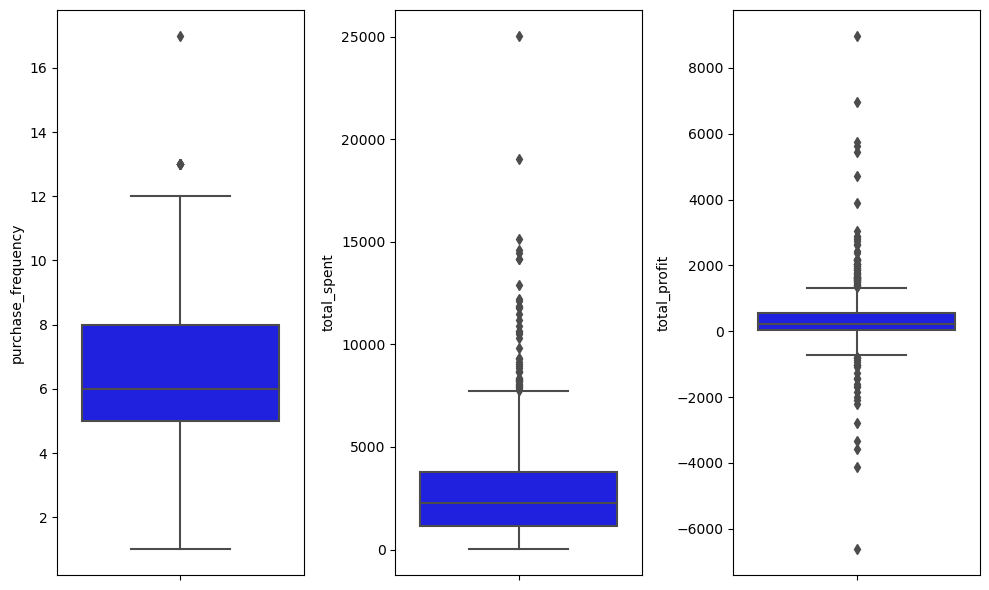

In [16]:
# Check outliers
numerical_columns = customer_summary.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 6))
for i in range(0, len(numerical_columns)):
    plt.subplot(1,len(numerical_columns), i+1)
    sns.boxplot(y=customer_summary[numerical_columns[i]], color='blue')
    plt.tight_layout()

Have no missing value, some outliers but we keep it original

In [17]:
#export data
customer_summary.to_excel("customer_summary.xlsx", index=False)

# 2: Analisis Profitabilitas dan Jumlah Pelanggan

c:\Users\Admin\anaconda3\lib\site-packages\seaborn\categorical.py:645: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  g_vals = grouped_vals.get_group(g)


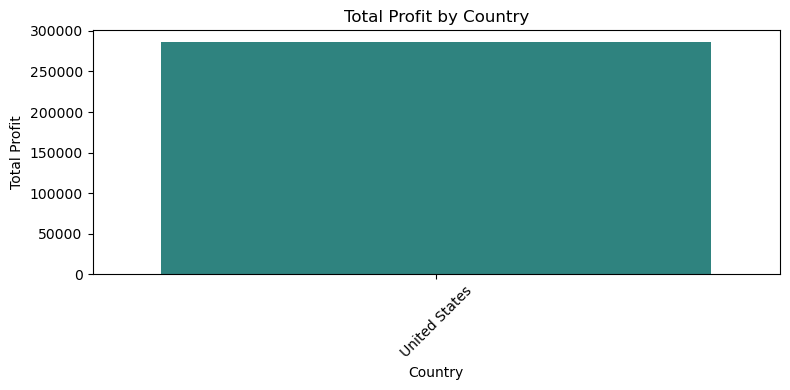

In [ ]:
country_profit = superstore_df.groupby('country')['profit'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(8, 4))
sns.barplot(x=country_profit.index, y=country_profit.values, palette='viridis')
plt.title('Total Profit by Country')
plt.ylabel('Total Profit')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3 : Analisis Perilaku Pembelian Pelanggan

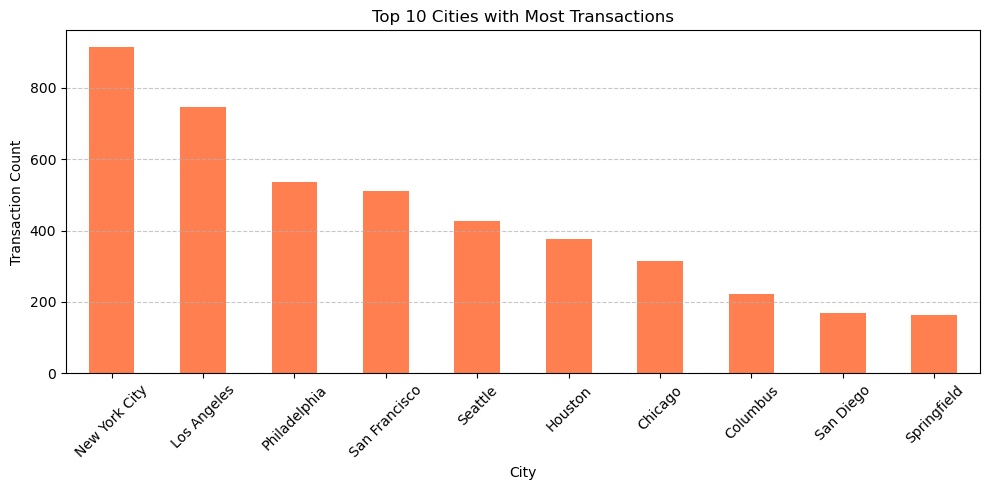

In [21]:
# 1. Kota dengan transaksi terbanyak
top_city = superstore_df['city'].value_counts().head(10)
plt.figure(figsize=(10, 5))
top_city.plot(kind='bar', color='coral')
plt.title('Top 10 Cities with Most Transactions')
plt.xlabel('City')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

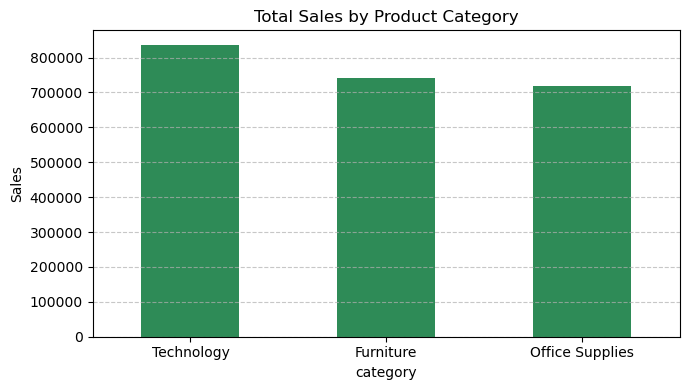

In [22]:
# 2. Kategori produk paling laris (berdasarkan total penjualan)
top_category = superstore_df.groupby('category')['sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(7, 4))
top_category.plot(kind='bar', color='seagreen')
plt.title('Total Sales by Product Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

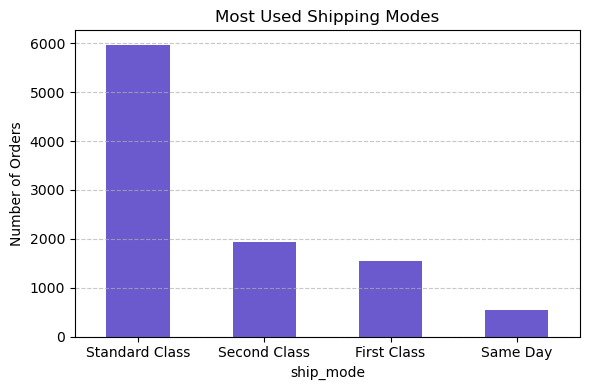

In [23]:
# 3. Jenis pengiriman paling sering digunakan
top_ship_mode = superstore_df['ship_mode'].value_counts()
plt.figure(figsize=(6, 4))
top_ship_mode.plot(kind='bar', color='slateblue')
plt.title('Most Used Shipping Modes')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()